# Week 5 — Additional Models

## Objectives

- Train a **Decision Tree Regressor**.
- Train a **Random Forest Regressor**.
- Compare their test-set $R^2$ values with the Week 4 Linear Regression baseline.
- Document the strengths and weaknesses of each model.

## Required input

This notebook expects the Week 3 output file:

`results/02/cleaned_preprocessed_data.csv`

The file should contain:

- `ClosePrice` as the target variable;
- `split` with values `train` and `test`;
- numeric preprocessed feature columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load the cleaned Week 3 dataset

The notebook loads the encoded Week 3 dataset from `results/02/` and saves all Week 5 outputs inside `results/04/`.


In [2]:
working_dir = Path.cwd()

project_root = (
    working_dir.parent
    if working_dir.name.lower() == "notebooks"
    else working_dir
)

results_dir = project_root / "results" / "04"
results_dir.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    project_root / "results" / "02" / "cleaned_preprocessed_data.csv",
    project_root / "cleaned_preprocessed_data.csv",
    working_dir / "cleaned_preprocessed_data.csv",
]

data_path = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if data_path is None:
    searched_locations = "\n".join(
        f"- {path}"
        for path in candidate_paths
    )

    raise FileNotFoundError(
        "Could not find cleaned_preprocessed_data.csv.\n"
        "Searched these locations:\n"
        f"{searched_locations}"
    )

df = pd.read_csv(
    data_path,
    low_memory=False,
)

df.columns = df.columns.str.strip()

print(f"Loaded file: {data_path.name}")
print(f"Dataset shape: {df.shape}")
print("Output folder: results/04/")

df.head()


Loaded file: cleaned_preprocessed_data.csv
Dataset shape: (61727, 2449)
Output folder: results/04/


,LivingArea,Bedrooms,Bathrooms,LotSize,YearBuilt,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing,YearBuilt_missing,CountyOrParish_Alameda,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,...,PostalCode_95948,PostalCode_95949,PostalCode_95953,PostalCode_95954,PostalCode_95958,PostalCode_95961,PostalCode_95963,PostalCode_95965,PostalCode_95966,PostalCode_95968,PostalCode_95969,PostalCode_95971,PostalCode_95973,PostalCode_95979,PostalCode_95988,PostalCode_95991,PostalCode_95993,PostalCode_96001,PostalCode_96002,PostalCode_96003,PostalCode_96007,PostalCode_96019,PostalCode_96021,PostalCode_96022,PostalCode_96025,PostalCode_96029,PostalCode_96035,PostalCode_96041,PostalCode_96044,PostalCode_96052,PostalCode_96055,PostalCode_96063,PostalCode_96067,PostalCode_96073,PostalCode_96080,PostalCode_96088,PostalCode_96091,PostalCode_96092,PostalCode_96093,PostalCode_96094,PostalCode_96097,PostalCode_96101,PostalCode_96106,PostalCode_96114,PostalCode_96130,PostalCode_96137,PostalCode_96143,PostalCode_96150,ClosePrice,split
0,-0.0058,0.5216,-0.5641,-0.0217,-0.3009,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,998,000.0000",train
1,0.9636,0.5216,1.1989,-0.0205,-0.6978,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"2,214,421.0000",train
2,-0.4408,0.5216,-0.5641,-0.0219,0.0599,-0.0215,0.0000,-0.0045,-0.1340,-0.0242,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000

## 2. Validate the required columns


In [3]:
target_col = "ClosePrice"
split_col = "split"

required_cols = [target_col, split_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Split counts:")
print(df[split_col].astype(str).str.strip().str.lower().value_counts(dropna=False))


Split counts:
split
train    49703
test     12024
Name: count, dtype: int64


## 3. Create the chronological training and test sets

The Week 3 preprocessing notebook used the most recent month as the test set. This notebook keeps that same split and does not create a random split.


In [4]:
split_values = df[split_col].astype(str).str.strip().str.lower()

train_df = df.loc[split_values == "train"].copy()
test_df = df.loc[split_values == "test"].copy()

if train_df.empty or test_df.empty:
    raise ValueError(
        "The split column must contain both train and test observations."
    )

print("Training observations:", len(train_df))
print("Test observations:", len(test_df))


Training observations: 49703
Test observations: 12024


## 4. Separate predictors and target

Only numeric columns are used as predictors. `ClosePrice` and `split` are excluded from the feature matrix.


In [5]:
feature_cols = [
    col for col in df.columns
    if col not in [target_col, split_col]
    and pd.api.types.is_numeric_dtype(df[col])
]

if not feature_cols:
    raise ValueError("No numeric predictor columns were found.")

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = pd.to_numeric(train_df[target_col], errors="coerce")
y_test = pd.to_numeric(test_df[target_col], errors="coerce")

print("Number of predictor columns:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Number of predictor columns: 2447
X_train shape: (49703, 2447)
X_test shape: (12024, 2447)


## 5. Final missing-value safeguard

Week 3 should already have handled missing values. This step replaces any remaining infinite values with missing values and fills them using training-set medians.


In [6]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

train_target_mask = y_train.notna()
test_target_mask = y_test.notna()

X_train = X_train.loc[train_target_mask].copy()
y_train = y_train.loc[train_target_mask].copy()

X_test = X_test.loc[test_target_mask].copy()
y_test = y_test.loc[test_target_mask].copy()

train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

all_missing_cols = X_train.columns[X_train.isna().all()].tolist()
if all_missing_cols:
    X_train = X_train.drop(columns=all_missing_cols)
    X_test = X_test.drop(columns=all_missing_cols)
    feature_cols = [col for col in feature_cols if col not in all_missing_cols]
    print("Dropped all-missing columns:", all_missing_cols)

remaining_missing = int(X_train.isna().sum().sum() + X_test.isna().sum().sum())
print("Remaining missing feature values:", remaining_missing)


Remaining missing feature values: 0


## 6. Define the three models

Linear Regression is included again so all three models are evaluated on exactly the same observations.

The tree models use basic regularization settings to reduce extreme overfitting and keep computation manageable.


In [7]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
}

models


{'Linear Regression': LinearRegression(),
 'Decision Tree': DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=42),
 'Random Forest': RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                       n_estimators=50, n_jobs=-1, random_state=42)}

## 7. Train and evaluate all models

The required metric is test-set $R^2$. Train $R^2$, test MAE, and test RMSE are also recorded to help explain model behavior.


In [8]:
results = []
predictions = {}
fitted_models = {}

for model_name, model in models.items():
    start_time = time.time()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    elapsed_time = time.time() - start_time

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append({
        "Model": model_name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "R2_Gap": train_r2 - test_r2,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
        "Training_Time_Seconds": elapsed_time
    })

    predictions[model_name] = test_pred
    fitted_models[model_name] = model

results_df = pd.DataFrame(results).sort_values(
    "Test_R2", ascending=False
).reset_index(drop=True)

results_df


,Model,Train_R2,Test_R2,R2_Gap,Test_MAE,Test_RMSE,Training_Time_Seconds
0,Linear Regression,0.0313,0.2426,-0.2113,"437,938.1016","1,460,357.1943",11.5365
1,Random Forest,0.2010,0.0882,0.1128,"573,829.3057","1,602,339.2473",3.8313
2,Decision Tree,0.1913,-2.3601,2.5514,"460,155.9763","3,075,981.4101",7.0449


## 8. Compare test $R^2$ against the Linear Regression baseline

A positive improvement means the model has a higher test $R^2$ than Linear Regression.


In [9]:
baseline_r2 = results_df.loc[
    results_df["Model"] == "Linear Regression", "Test_R2"
].iloc[0]

results_df["R2_Improvement_vs_Baseline"] = (
    results_df["Test_R2"] - baseline_r2
)

comparison_cols = [
    "Model",
    "Train_R2",
    "Test_R2",
    "R2_Improvement_vs_Baseline",
    "R2_Gap",
    "Test_MAE",
    "Test_RMSE",
    "Training_Time_Seconds"
]

results_df[comparison_cols]


,Model,Train_R2,Test_R2,R2_Improvement_vs_Baseline,R2_Gap,Test_MAE,Test_RMSE,Training_Time_Seconds
0,Linear Regression,0.0313,0.2426,0.0000,-0.2113,"437,938.1016","1,460,357.1943",11.5365
1,Random Forest,0.2010,0.0882,-0.1544,0.1128,"573,829.3057","1,602,339.2473",3.8313
2,Decision Tree,0.1913,-2.3601,-2.6027,2.5514,"460,155.9763","3,075,981.4101",7.0449


## 9. Plot the test-set $R^2$ comparison


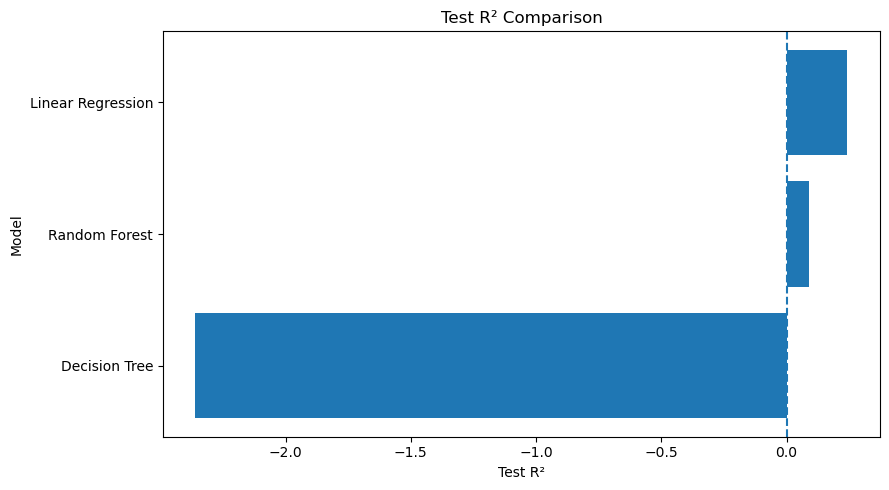

Saved: results/04/model_comparison_test_r2.png


In [10]:
plot_df = results_df.sort_values(
    "Test_R2",
    ascending=True,
)

plt.figure(figsize=(9, 5))
plt.barh(
    plot_df["Model"],
    plot_df["Test_R2"],
)
plt.axvline(0, linestyle="--")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Test R² Comparison")
plt.tight_layout()

comparison_plot_path = (
    results_dir
    / "model_comparison_test_r2.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved: "
    "results/04/model_comparison_test_r2.png"
)


## 10. Actual versus predicted prices

These plots show how closely each model's predictions follow the actual closing prices.


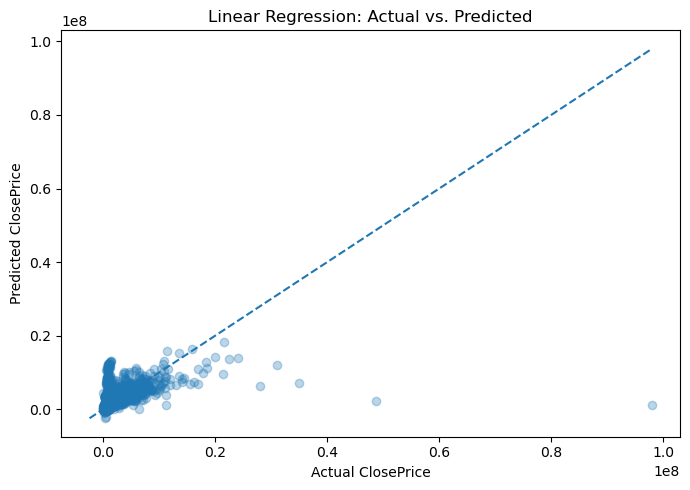

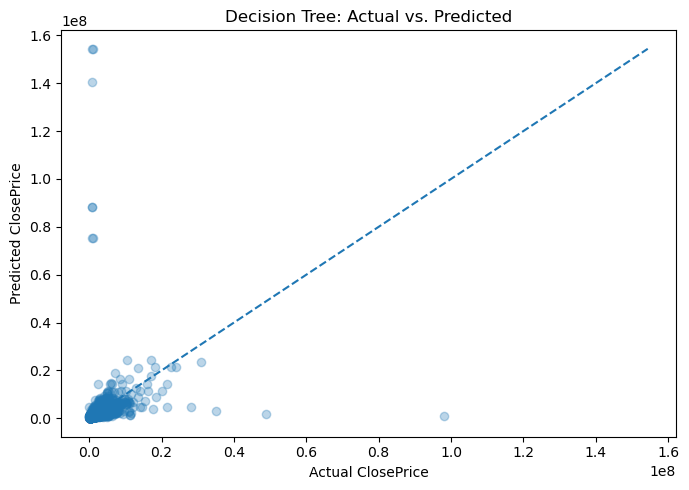

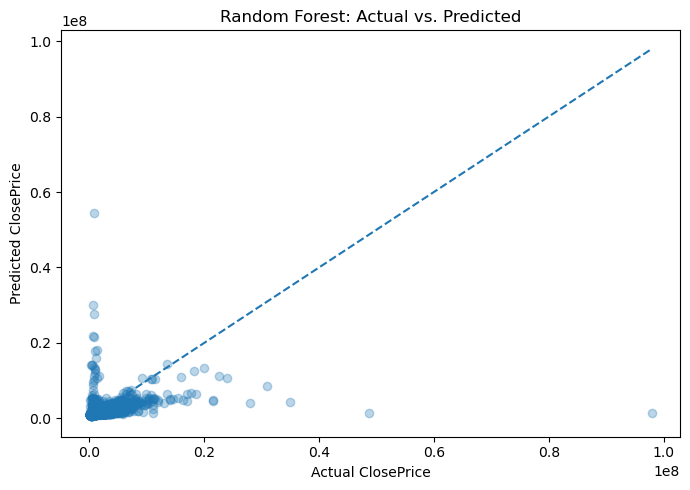

In [11]:
for model_name, test_pred in predictions.items():
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, test_pred, alpha=0.30)

    plot_min = min(y_test.min(), test_pred.min())
    plot_max = max(y_test.max(), test_pred.max())
    plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--")

    plt.xlabel("Actual ClosePrice")
    plt.ylabel("Predicted ClosePrice")
    plt.title(f"{model_name}: Actual vs. Predicted")
    plt.tight_layout()
    plt.show()


## 11. Random Forest feature importance

Random Forest feature importance gives a rough indication of which predictors contributed most to its decisions.


In [12]:
random_forest_model = fitted_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(20)


,Feature,Importance
0,LivingArea,0.2514
3,LotSize,0.2392
4,YearBuilt,0.1582
2,Bathrooms,0.1085
1,Bedrooms,0.0683
880,City_Valley Center,0.0215
1413,PostalCode_92395,0.0159
1239,PostalCode_91911,0.0148
1293,PostalCode_92082,0.0107
140,City_Beverly Hills,0.0082


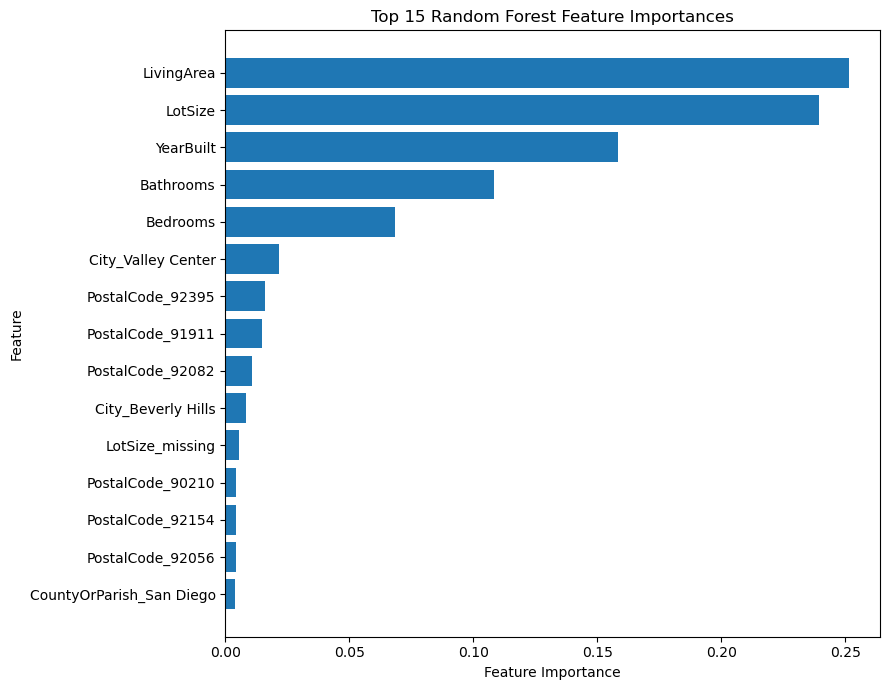

Saved: results/04/random_forest_feature_importance.png


In [13]:
top_features = (
    importance_df
    .head(15)
    .sort_values(
        "Importance",
        ascending=True,
    )
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Random Forest Feature Importances"
)
plt.tight_layout()

importance_plot_path = (
    results_dir
    / "random_forest_feature_importance.png"
)

plt.savefig(
    importance_plot_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved: "
    "results/04/random_forest_feature_importance.png"
)


## 12. Automatically summarize model behavior

The train-test $R^2$ gap helps identify possible overfitting. A large positive gap means a model fits the training data much better than the test data.


In [14]:
best_model_row = results_df.loc[results_df["Test_R2"].idxmax()]
largest_gap_row = results_df.loc[results_df["R2_Gap"].idxmax()]

print(
    f"Best test-set model: {best_model_row['Model']} "
    f"with Test R² = {best_model_row['Test_R2']:.4f}"
)

print(
    f"Largest train-test R² gap: {largest_gap_row['Model']} "
    f"with a gap of {largest_gap_row['R2_Gap']:.4f}"
)

for _, row in results_df.iterrows():
    improvement = row["R2_Improvement_vs_Baseline"]

    if row["Model"] == "Linear Regression":
        comparison_text = "This is the baseline model."
    elif improvement > 0:
        comparison_text = f"It improved test R² over the baseline by {improvement:.4f}."
    else:
        comparison_text = f"It performed below the baseline by {abs(improvement):.4f} R²."

    print(
        f"\n{row['Model']}: "
        f"Train R² = {row['Train_R2']:.4f}, "
        f"Test R² = {row['Test_R2']:.4f}. "
        f"{comparison_text}"
    )


Best test-set model: Linear Regression with Test R² = 0.2426
Largest train-test R² gap: Decision Tree with a gap of 2.5514

Linear Regression: Train R² = 0.0313, Test R² = 0.2426. This is the baseline model.

Random Forest: Train R² = 0.2010, Test R² = 0.0882. It performed below the baseline by 0.1544 R².

Decision Tree: Train R² = 0.1913, Test R² = -2.3601. It performed below the baseline by 2.6027 R².


## 13. Model strengths and weaknesses

### Linear Regression

**Strengths**

- Simple and fast to train.
- Easy to interpret.
- Provides a useful baseline.
- Works well when relationships are approximately linear.

**Weaknesses**

- Cannot naturally capture complex nonlinear relationships.
- Can be sensitive to extreme observations and multicollinearity.
- May underfit complicated real estate pricing patterns.

### Decision Tree

**Strengths**

- Captures nonlinear relationships and interactions.
- Does not require feature scaling.
- Easy to visualize when the tree is small.

**Weaknesses**

- A single tree can overfit the training data.
- Predictions can change substantially after small changes in the data.
- Usually generalizes less reliably than an ensemble model.

### Random Forest

**Strengths**

- Combines many trees and usually generalizes better than one decision tree.
- Captures nonlinear relationships and interactions.
- Is less sensitive to individual noisy observations than a single tree.
- Provides feature-importance estimates.

**Weaknesses**

- Requires more computation and memory.
- Is less interpretable than Linear Regression or a small Decision Tree.
- Can still overfit when trees are too deep or insufficiently regularized.


## 14. Save the model comparison results


In [15]:
results_df.to_csv(
    results_dir
    / "model_comparison_results.csv",
    index=False,
)

importance_df.to_csv(
    results_dir
    / "random_forest_feature_importance.csv",
    index=False,
)

print(
    "Saved: "
    "results/04/model_comparison_results.csv"
)
print(
    "Saved: "
    "results/04/random_forest_feature_importance.csv"
)

results_df


Saved: results/04/model_comparison_results.csv
Saved: results/04/random_forest_feature_importance.csv


,Model,Train_R2,Test_R2,R2_Gap,Test_MAE,Test_RMSE,Training_Time_Seconds,R2_Improvement_vs_Baseline
0,Linear Regression,0.0313,0.2426,-0.2113,"437,938.1016","1,460,357.1943",11.5365,0.0000
1,Random Forest,0.2010,0.0882,0.1128,"573,829.3057","1,602,339.2473",3.8313,-0.1544
2,Decision Tree,0.1913,-2.3601,2.5514,"460,155.9763","3,075,981.4101",7.0449,-2.6027


## Conclusion

This notebook compared Linear Regression, Decision Tree, and Random Forest using the same chronological training and test sets. The main comparison metric was test-set $R^2$.

The model with the highest test $R^2$ is the strongest model among these initial candidates. The results show that Linear Regression achieved the highest test-set $R^2$, with a value of 0.2426. Random Forest achieved a test $R^2$ of 0.0882, while Decision Tree produced a negative test $R^2$ of -2.3601. Therefore, Linear Regression remains the strongest model among these three initial candidates. The large train-test $R^2$ gap for Decision Tree also indicates poor generalization and possible overfitting.

Generated supporting files:

- `results/04/model_comparison_results.csv`
- `results/04/model_comparison_test_r2.png`
- `results/04/random_forest_feature_importance.csv`
- `results/04/random_forest_feature_importance.png`
